# REGIÕES DO BLOCO DE MARLIM
Separa tiles reais de 128³ dos quatro patches (`1200`, `1300`, `1400`, `2600`) em três regiões —
`calm`, `faulted` e `dead` — e grava cada uma em `files/<região>/marlim_<patch>_<região>_<n>.npy`,
no eixo `(inline, z, xline)` e na escala [0,1] dos `.dat`. O índice sai em `files/DataBase.csv`.

A região vem do **conteúdo do tile**, não de uma faixa fixa de z como no `Generator2.ipynb`: lá o
`calmo` (z 250–620) pegava água no leste, onde o fundo do mar mergulha até z≈420, as faixas cortavam
as transições no meio e o `2600`, em que a falha sobe até o fundo do mar, era tratado como os outros.

| região | regra |
|---|---|
| `calm` | inteiro no intervalo refletivo, nenhuma falha anotada a menos de `FAULT_GAP` px e mais contínuo que 95% dos tiles em que o especialista desenhou falha |
| `faulted` | inteiro no intervalo refletivo e cruzado por pelo menos `TILE` px de falha anotada, o equivalente a uma falha de cima a baixo |
| `dead` | inteiro na zona morta, sem nenhum voxel com envelope de refletor e nenhuma falha anotada a menos de `FAULT_GAP` px |

**Intervalo refletivo** é o trecho entre o fundo do mar e o topo da zona morta. Todos os limiares são
medidos no próprio bloco. Dois tiles da mesma região dividem no máximo `MAX_OVERLAP` do volume.

In [4]:
import os, re, json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import cv2
from concurrent.futures import ThreadPoolExecutor
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from PIL import Image
from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize
from tqdm import tqdm
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [5]:
PATCH_IDS  = ['1200', '1300', '1400', '2600']
MARLIM_DIR = '../../../Dataset/marlim'
PATCH_DIR  = '../../files/patches'
OUT_DIR    = 'files'
COLORS     = {'calm': 'deepskyblue', 'faulted': 'red', 'dead': 'gold'}

TILE, STEP    = 128, 16      # tile gravado e passo da grade de candidatos
MAX_OVERLAP   = 0.25         # fração máxima do volume que dois tiles da mesma região dividem
WATER_TOL     = 0.02         # |amplitude| que já não é água: acima do precursor do fundo do mar (≤ 0.006)
SEAFLOOR_GAP  = 16           # a reflexão do fundo do mar ocupa ~10 amostras; 16 a deixa fora do tile
ENV_SIGMA     = 12           # janela gaussiana do envelope RMS
SEMBLANCE_MIN = 0.8          # semblance abaixo disso marca o voxel como descontínuo
FAULT_GAP     = TILE // 2    # folga até a falha anotada: ela anda de lado entre as inlines do tile
CALM_QUANTILE = 5            # o calm é mais contínuo que 95% dos tiles com falha do especialista
NJOBS         = 8

TILE, STEP, MAX_OVERLAP, FAULT_GAP

(128, 16, 0.25, 64)

# BLOCO DE MARLIM
`MarlimBlock` monta o slab de cada patch a partir dos `.dat` de `../../../Dataset/marlim/patch_<id>`.
O `original_shape` do `patch_metadata.json` diz 64 inlines, mas esse é só o miolo: os **128 inlines**
de cada `.dat` são dados reais — inlines vizinhos correlacionam ≥ 0.99 do primeiro ao último, sem
emenda em 32/96 e sem simetria de espelho, enquanto as bordas em z e xline, onde não há dado, têm
padding por reflexão. Por isso o slab tem 128 inlines e todo tile 128³ ocupa todos eles.

A água é uma constante (o valor de z = 0); o **fundo do mar** é a primeira amostra de cada traço que
sai dela por mais de `WATER_TOL`, e um traço que nunca sai é **traço morto** (a xline 0 em todos os
patches, mais algumas xlines de borda no `1400` e no `2600`). A **inline anotada** é a de maior
correlação com o `<id>.png`, e `check` confere o slab montado bit a bit contra `.dat` inteiros
sorteados longe das bordas.

In [6]:
class MarlimBlock:
    def __init__(self, patchId, folder=MARLIM_DIR, patches=PATCH_DIR):
        self.patchId = patchId
        self.folder  = f'{folder}/patch_{patchId}'
        self.images  = f'{patches}/{patchId}'

    # SLAB MONTADO, NÍVEL DA ÁGUA, FUNDO DO MAR, TRAÇOS MORTOS, ANOTAÇÃO E A INLINE EM QUE ELA FOI FEITA
    def update(self):
        meta = json.load(open(f'{self.folder}/patch_metadata.json'))

        if meta['grid_shape'][0] != 1:
            raise ValueError(f'patch_{self.patchId}: esperado um .dat no eixo inline, grade {meta["grid_shape"]}')

        self.size    = meta['patch_size']
        self.overlap = meta['overlap_voxels']
        self.stride  = self.size - 2 * self.overlap
        self.shape   = (self.size, *meta['original_shape'][1:])
        self.volume  = self.process()
        self.water   = float(np.median(self.volume[:, 0]))

        rock = np.abs(self.volume - self.water) > WATER_TOL
        self.deadTrace  = ~rock.any(1)
        self.seafloor   = np.argmax(rock, axis=1)
        self.annotation = np.asarray(Image.open(f'{self.images}/{self.patchId}_interpretado.png').convert('L')) > 128

        norm = lambda a: (a - a.mean()) / (a.std() + 1e-9)
        ref  = norm(np.asarray(Image.open(f'{self.images}/{self.patchId}.png').convert('L'), np.float32))
        corr = [float((norm(sec) * ref).mean()) for sec in self.volume]
        self.inline = int(np.argmax(corr))
        self.match  = max(corr)
        return self

    def patch(self, name):
        return np.fromfile(f'{self.folder}/{name}', np.float32).reshape((self.size,) * 3)

    def get(self, z0, x0, size=TILE):
        return self.volume[:, z0:z0 + size, x0:x0 + size].copy()

    # MIOLO DE CADA .dat EM z E xline, OS 128 INLINES INTEIROS; O ÚLTIMO .dat DE CADA EIXO ENCOSTA NO FIM
    def process(self):
        vol    = np.zeros(self.shape, np.float32)
        filled = np.zeros(self.shape[1:], bool)

        for name in tqdm(sorted(os.listdir(self.folder)), desc=f'patch_{self.patchId}'):
            found = re.match(r'patch_d\d+_h(\d+)_w(\d+)\.dat$', name)

            if not found:
                continue

            z0, x0 = [max(0, n - self.stride) if i == n // self.stride else i * self.stride
                      for i, n in zip(map(int, found.groups()), self.shape[1:])]
            nz, nx = min(self.stride, self.shape[1] - z0), min(self.stride, self.shape[2] - x0)
            vol[:, z0:z0 + nz, x0:x0 + nx] = self.patch(name)[:, self.overlap:self.overlap + nz, self.overlap:self.overlap + nx]
            filled[z0:z0 + nz, x0:x0 + nx] = True

        if not filled.all():
            raise ValueError(f'patch_{self.patchId}: {(~filled).sum()} colunas (z, xline) sem nenhum .dat')

        return vol

    # ENVELOPE RMS (MÉDIA GAUSSIANA DE a², a = AMOSTRA − ÁGUA) DAS INLINES PEDIDAS
    def envelope(self, inlines=None):
        inlines = list(range(self.shape[0]) if inlines is None else inlines)
        out     = np.empty((len(inlines), *self.shape[1:]), np.float32)
        fill    = lambda k: out.__setitem__(k, np.sqrt(self.gauss((self.volume[inlines[k]] - self.water) ** 2, ENV_SIGMA)))

        with ThreadPoolExecutor(NJOBS) as pool:
            list(pool.map(fill, range(len(inlines))))

        return out

    # FRAÇÃO DAS INLINES AMOSTRADAS EM QUE CADA (z, xline) É DESCONTÍNUO
    def discontinuity(self, every=4):
        inlines = range(every // 2, self.shape[0], every)
        flag    = lambda i: (self.semblance(self.volume[i] - self.water) < SEMBLANCE_MIN).astype(np.float32)

        with ThreadPoolExecutor(NJOBS) as pool:
            return sum(pool.map(flag, inlines)) / len(inlines)

    # CONFERE O SLAB BIT A BIT CONTRA .dat INTEIROS SORTEADOS LONGE DAS BORDAS, ONDE O .dat NÃO TEM PADDING
    def check(self, n=24, seed=0):
        rng  = np.random.default_rng(seed)
        last = [(s + self.overlap - self.size) // self.stride for s in self.shape[1:]]

        for h, w in zip(rng.integers(1, last[0] + 1, n), rng.integers(1, last[1] + 1, n)):
            z0, x0 = h * self.stride - self.overlap, w * self.stride - self.overlap

            if not np.array_equal(self.patch(f'patch_d000_h{h:03d}_w{w:03d}.dat'), self.get(z0, x0, self.size)):
                raise ValueError(f'patch_{self.patchId}: slab difere de patch_d000_h{h:03d}_w{w:03d}.dat')
        return n

    @staticmethod
    def gauss(img, sigma):
        return cv2.GaussianBlur(img, (0, 0), sigmaX=sigma, sigmaY=sigma, borderType=cv2.BORDER_REFLECT)

    # SEMBLANCE DE 5 TRAÇOS SEGUINDO O MERGULHO LOCAL DO TENSOR DE ESTRUTURA: ~1 NO REFLETOR CONTÍNUO, CAI NA FALHA
    @classmethod
    def semblance(cls, sec, half=2, win=4):
        smooth = cls.gauss(sec, 1.0)
        gz     = cv2.Sobel(smooth, cv2.CV_32F, 0, 1, ksize=3)
        gx     = cv2.Sobel(smooth, cv2.CV_32F, 1, 0, ksize=3)
        Jzz, Jxx, Jzx = cls.gauss(gz * gz, 4.0), cls.gauss(gx * gx, 4.0), cls.gauss(gz * gx, 4.0)
        dip    = np.clip(-np.tan(0.5 * np.arctan2(2 * Jzx, Jzz - Jxx)), -3, 3)

        zz, xx = np.mgrid[:sec.shape[0], :sec.shape[1]].astype(np.float32)
        traces = [cv2.remap(sec, xx + k, zz + dip * k, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
                  for k in range(-half, half + 1)]
        window = np.ones((2 * win + 1, 1), np.float32)
        num    = cv2.filter2D(sum(traces) ** 2, -1, window, borderType=cv2.BORDER_REFLECT)
        den    = cv2.filter2D(sum(t * t for t in traces) * len(traces), -1, window, borderType=cv2.BORDER_REFLECT)
        return num / (den + 1e-12)

    def info(self):
        live = ~self.deadTrace
        return {
            'patch': self.patchId, 'slab': self.shape, 'água': round(self.water, 5),
            'inline anotada': self.inline, 'r da inline': round(self.match, 3),
            'fundo do mar (z)': f'{self.seafloor[live].min()}–{self.seafloor[live].max()}',
            'traços mortos': int(self.deadTrace.sum())
        }


BLOCKS = {p: MarlimBlock(p).update() for p in PATCH_IDS}

pd.DataFrame([dict(b.info(), conferidos=b.check()) for b in BLOCKS.values()])

patch_2600: 100%|██████████| 911/911 [00:01<00:00, 462.66it/s]


,patch,slab,água,inline anotada,r da inline,fundo do mar (z),traços mortos,conferidos
0,1200,"(128, 1601, 2240)",0.50263,48,0.909,159–408,128,24
1,1300,"(128, 1601, 2240)",0.50263,84,0.909,158–413,128,24
2,1400,"(128, 1601, 2240)",0.50263,56,0.911,157–412,230,24
3,2600,"(128, 1601, 2240)",0.50263,40,1.000,168–425,1037,24


# TILES CANDIDATOS
`RegionFinder` mede cada tile da grade — origens a cada `STEP` em z e xline, o tile ocupando os 128
inlines — por imagem integral sobre mapas `(z, xline)` contados ao longo das inlines:

| medida | o que é |
|---|---|
| `reflective` | fração do tile entre o fundo do mar (+ `SEAFLOOR_GAP`) e o topo da zona morta, fora dos traços mortos |
| `deadZone` | fração do tile abaixo do topo da zona morta |
| `alive` | fração de voxels com envelope RMS acima do limiar de refletor vivo |
| `rms` | envelope RMS médio |
| `discontinuity` | fração de voxels com semblance < `SEMBLANCE_MIN`, numa inline a cada 4 |
| `faultLength` | pixels do esqueleto da falha anotada dentro do tile, ≈ linhas do tile que a falha cruza |
| `faultNear` | pixels a menos de `FAULT_GAP` px de uma falha anotada; 0 = nenhuma falha por perto |

Os dois limiares saem do bloco. **Refletor vivo**: Otsu no log do envelope abaixo do fundo do mar,
cujo histograma é bimodal (zona morta × refletores). **Topo da zona morta**: a amostra logo abaixo do
voxel vivo mais fundo de cada traço, com mediana lateral para ignorar manchas isoladas — pela energia
sozinha o intervalo fraco entre o pacote raso e a banda brilhante (z ≈ 600–850) se confundiria com a
zona morta, e é lá que está a maioria das falhas. **Descontinuidade máxima do `calm`**: o
p`CALM_QUANTILE` dos tiles em que o especialista desenhou falha. A anotação vale para o tile inteiro
porque todo tile contém a inline anotada.

In [7]:
class RegionFinder:
    def __init__(self, blocks):
        self.blocks  = blocks
        self.deadTop = {}
        self.maps    = {}
        self.limits  = {}

    # LIMIARES MEDIDOS NO BLOCO E A TABELA DE TODOS OS CANDIDATOS DOS QUATRO PATCHES
    def update(self, every=8):
        sample = []

        for block in self.blocks.values():
            inlines = np.arange(every // 2, block.shape[0], every)
            z       = np.arange(block.shape[1])[None, :, None]
            rock    = (z >= block.seafloor[inlines, None, :] + SEAFLOOR_GAP) & ~block.deadTrace[inlines, None, :]
            sample.append(np.log10(block.envelope(inlines)[rock][::every] + 1e-6))

        self.limits['alive'] = float(10 ** threshold_otsu(np.concatenate(sample)))
        self.tiles = pd.concat([self.process(b) for b in tqdm(self.blocks.values(), desc='medindo tiles')],
                               ignore_index=True)

        expert = (self.tiles.reflective == 1) & (self.tiles.faultLength >= TILE)
        self.limits['calm'] = float(np.percentile(self.tiles.discontinuity[expert], CALM_QUANTILE))
        return self

    # MAPAS (z, xline) DE UM PATCH, CONTADOS AO LONGO DOS 128 INLINES, E AS MEDIDAS DE CADA CANDIDATO
    def process(self, block):
        env   = block.envelope()
        alive = env > self.limits['alive']
        top   = ndi.median_filter(block.shape[1] - np.argmax(alive[:, ::-1], axis=1), size=(9, TILE + 1), mode='nearest')

        z     = np.arange(block.shape[1])[None, :, None]
        void  = (z < block.seafloor[:, None, :] + SEAFLOOR_GAP) | block.deadTrace[:, None, :]
        dead  = (z >= top[:, None, :]) & ~void
        cells = block.shape[0] * TILE * TILE

        self.deadTop[block.patchId] = top
        self.maps[block.patchId] = maps = {
            'reflective':    ((~void & ~dead).sum(0, dtype=np.int16), cells),
            'deadZone':      (dead.sum(0, dtype=np.int16), cells),
            'alive':         (alive.sum(0, dtype=np.int16), cells),
            'rms':           (env.sum(0), cells),
            'discontinuity': (block.discontinuity(), TILE ** 2),
            'faultLength':   (skeletonize(block.annotation), 1),
            'faultNear':     (ndi.distance_transform_edt(~block.annotation) <= FAULT_GAP, 1),
        }
        z0, x0 = self.grid(block.shape[1:])
        return pd.DataFrame({'patch': block.patchId, 'z0': z0, 'x0': x0,
                             **{k: self.boxSum(m) / n for k, (m, n) in maps.items()}})

    # GULOSO POR PATCH: MAIOR score PRIMEIRO, PULANDO QUEM DIVIDE MAIS QUE MAX_OVERLAP COM UM JÁ ESCOLHIDO
    def select(self, mask, score):
        chosen = []

        for _, group in self.tiles[mask].assign(score=score[mask]).groupby('patch'):
            kept = np.empty((0, 2))

            for index, z0, x0 in group.sort_values('score', ascending=False, kind='stable')[['z0', 'x0']].itertuples():
                shared = np.clip(TILE - np.abs(kept - (z0, x0)), 0, None).prod(1) / TILE ** 2

                if (shared <= MAX_OVERLAP).all():
                    kept = np.vstack([kept, (z0, x0)])
                    chosen.append(index)

        return self.tiles.loc[chosen].assign(score=score.loc[chosen]).sort_values(['patch', 'z0', 'x0'])

    # ORIGENS (z0, x0) DA GRADE DE CANDIDATOS NUMA SEÇÃO (z, xline)
    @staticmethod
    def grid(shape, tile=TILE, step=STEP):
        axes = [np.arange(0, n - tile + 1, step) for n in shape]
        return [g.ravel() for g in np.meshgrid(*axes, indexing='ij')]

    # SOMA DE a EM CADA JANELA TILE×TILE DA GRADE, POR IMAGEM INTEGRAL
    @classmethod
    def boxSum(cls, a, tile=TILE, step=STEP):
        acc    = np.pad(a.astype(np.float64).cumsum(0).cumsum(1), ((1, 0), (1, 0)))
        z0, x0 = cls.grid(a.shape, tile, step)
        return acc[z0 + tile, x0 + tile] - acc[z0, x0 + tile] - acc[z0 + tile, x0] + acc[z0, x0]

    # GRADE 3×3 COM A INLINE ANOTADA DE 9 TILES, DO MAIS TÍPICO (1) AO LIMÍTROFE (9) PELO score DA REGIÃO
    def show(self, region, index):
        ranked = index.sort_values('score', ascending=False, kind='stable')
        picks  = ranked.iloc[np.unique(np.linspace(0, len(ranked) - 1, 9).round().astype(int))]
        fig    = plt.figure(figsize=(15, 17))

        for i, row in enumerate(picks.itertuples()):
            block  = self.blocks[row.patch]
            zf, xf = np.nonzero(block.annotation[row.z0:row.z0 + TILE, row.x0:row.x0 + TILE])

            plt.subplot(3, 3, i + 1)
            plt.imshow(block.volume[block.inline, row.z0:row.z0 + TILE, row.x0:row.x0 + TILE], cmap='gray', vmin=0, vmax=1)
            plt.scatter(xf, zf, s=1, c='lime')
            plt.title(f'{i + 1}. {row.id}\nz={row.z0}  x={row.x0}  σ={row.img_std:.3f}  '
                      f'descont.={row.discontinuity:.3f}  falha={row.faultLength:.0f}px', fontsize=9)
            plt.axis('off')

        fig.suptitle(f'REGIÃO {region.upper()} — {len(index)} tiles, do mais típico (1) ao limítrofe (9);\n falha do especialista em verde', fontsize=13)
        plt.tight_layout(rect=(0, 0, 1, 0.97))
        plt.show()

    # INLINE ANOTADA DE CADA PATCH COM O FUNDO DO MAR, O TOPO DA ZONA MORTA E OS TILES DE CADA REGIÃO
    def plot(self, index):
        fig, axes = plt.subplots(2, 2, figsize=(24, 18))

        for ax, (patch, block) in zip(axes.ravel(), self.blocks.items()):
            rows   = index[index.patch == patch]
            zf, xf = np.nonzero(block.annotation)

            ax.imshow(block.volume[block.inline], cmap='gray', vmin=0, vmax=1)
            ax.scatter(xf, zf, s=0.2, c='lime')
            ax.plot(np.where(block.deadTrace[block.inline], np.nan, block.seafloor[block.inline]), c='cyan', lw=1.2)
            ax.plot(self.deadTop[patch][block.inline], c='darkorange', lw=1.2)

            for row in rows.itertuples():
                ax.add_patch(Rectangle((row.x0, row.z0), TILE, TILE, fill=False, ec=COLORS[row.region], lw=1.2))

            counts = rows.region.value_counts()
            ax.set_title(f'patch {patch} (inline {block.inline})   '
                         + '   '.join(f'{r}: {counts.get(r, 0)}' for r in COLORS), fontsize=12)

        handles  = [Patch(fill=False, ec=c, lw=2, label=r) for r, c in COLORS.items()]
        handles += [Line2D([], [], c='cyan', label='fundo do mar'), Line2D([], [], c='darkorange', label='topo da zona morta'),
                    Line2D([], [], c='lime', label='falha anotada')]
        fig.legend(handles=handles, loc='lower center', ncol=6, fontsize=12)
        plt.tight_layout(rect=(0, 0.03, 1, 1))
        plt.show()

    # RELÊ CADA ARQUIVO E REFAZ AS MEDIDAS SOMANDO OS MAPAS NO TILE: PEGA ARQUIVO CORROMPIDO E GRADE DESLOCADA
    def check(self, index):
        for (region, patch), group in index.groupby(['region', 'patch']):
            shared = (np.clip(TILE - np.abs(group.z0.values[:, None] - group.z0.values), 0, None)
                      * np.clip(TILE - np.abs(group.x0.values[:, None] - group.x0.values), 0, None) / TILE ** 2)
            np.fill_diagonal(shared, 0)

            if shared.max() > MAX_OVERLAP:
                raise ValueError(f'{region}/{patch}: dois tiles dividem {shared.max():.2f} do volume')

        for region, group in index.groupby('region'):
            if sorted(os.listdir(f'{OUT_DIR}/{region}')) != sorted(group.id):
                raise ValueError(f'{OUT_DIR}/{region} não bate com o índice')

        for row in tqdm(index.itertuples(), total=len(index), desc='conferindo'):
            tile = np.load(row.img_path)

            if tile.shape != (TILE,) * 3 or tile.dtype != np.float32 or not (0 <= tile.min() <= tile.max() <= 1):
                raise ValueError(f'{row.id}: shape {tile.shape}, tipo {tile.dtype}, faixa [{tile.min()}, {tile.max()}]')

            if not np.array_equal(tile, self.blocks[row.patch].get(row.z0, row.x0)):
                raise ValueError(f'{row.id}: conteúdo difere do slab em z={row.z0} x={row.x0}')

            for key, (m, n) in self.maps[row.patch].items():
                direct = m[row.z0:row.z0 + TILE, row.x0:row.x0 + TILE].sum(dtype=np.float64) / n

                if not np.isclose(direct, getattr(row, key), rtol=1e-6, atol=1e-9):
                    raise ValueError(f'{row.id}: {key} da grade = {getattr(row, key)}, somado no tile = {direct}')

        return index.groupby(['region', 'patch']).size().unstack(fill_value=0).reindex(list(COLORS), fill_value=0)

    # GRAVA files/<região>/marlim_<patch>_<região>_<n>.npy EM (inline, z, xline) E DEVOLVE O ÍNDICE DA REGIÃO
    def export(self, region, mask, score):
        folder = os.path.abspath(f'{OUT_DIR}/{region}')
        shutil.rmtree(folder, ignore_errors=True)
        os.makedirs(folder)
        rows = []

        for patch, group in self.select(mask, score).groupby('patch'):
            block = self.blocks[patch]

            for n, row in enumerate(group.itertuples()):
                tile = block.get(row.z0, row.x0)
                path = f'{folder}/marlim_{patch}_{region}_{n:03d}.npy'
                np.save(path, tile)
                rows.append({
                    'id': os.path.basename(path), 'region': region, 'patch': patch,
                    'z0': row.z0, 'x0': row.x0, 'inline': block.inline,
                    'img_min': float(tile.min()), 'img_max': float(tile.max()),
                    'img_mean': float(tile.mean()), 'img_std': float(tile.std()),
                    **{k: getattr(row, k) for k in self.maps[patch]}, 'score': row.score,
                    'shape': str(tile.shape), 'img_path': path}
                )

        index = pd.DataFrame(rows)
        print(f'{region}: {int(mask.sum())} candidatos -> {len(index)} tiles\n{index.groupby("patch").size().to_dict()} em {OUT_DIR}/{region}')
        return index


finder = RegionFinder(BLOCKS).update()
tiles  = finder.tiles

print(f'refletor vivo: envelope > {finder.limits["alive"]:.4f} (Otsu)')
print(f'calm: descontinuidade <= {finder.limits["calm"]:.4f}   (p{CALM_QUANTILE} dos tiles com falha do especialista)')

tiles.groupby('patch').agg(
    candidatos=('z0', 'size'),
    refletivos=('reflective', lambda v: int((v == 1).sum())),
    zona_morta=('deadZone',   lambda v: int((v == 1).sum())),
    com_falha=('faultLength', lambda v: int((v >= TILE).sum()))
)

medindo tiles: 100%|██████████| 4/4 [01:17<00:00, 19.37s/it]

refletor vivo: envelope > 0.0552   (Otsu)
calm: descontinuidade <= 0.0107   (p5 dos tiles com falha do especialista)


,candidatos,refletivos,zona_morta,com_falha
patch,,,,
1200,12369,5933,1827,1641
1300,12369,5955,1895,1074
1400,12369,5919,1801,1066
2600,12369,5535,2127,3255


# REGIÃO CALM
Tile inteiro no intervalo refletivo, **nenhuma falha anotada a menos de `FAULT_GAP` px** e
descontinuidade até o limite medido acima. A folga de meio tile existe porque a falha, anotada numa
inline só, anda de lado nas outras; e a continuidade é medida em 32 inlines do tile, então uma falha
fora da inline anotada também derruba o candidato. Os mais contínuos entram primeiro.

calm: 4207 candidatos -> 149 tiles {'1200': 33, '1300': 44, '1400': 41, '2600': 31} em files/calm


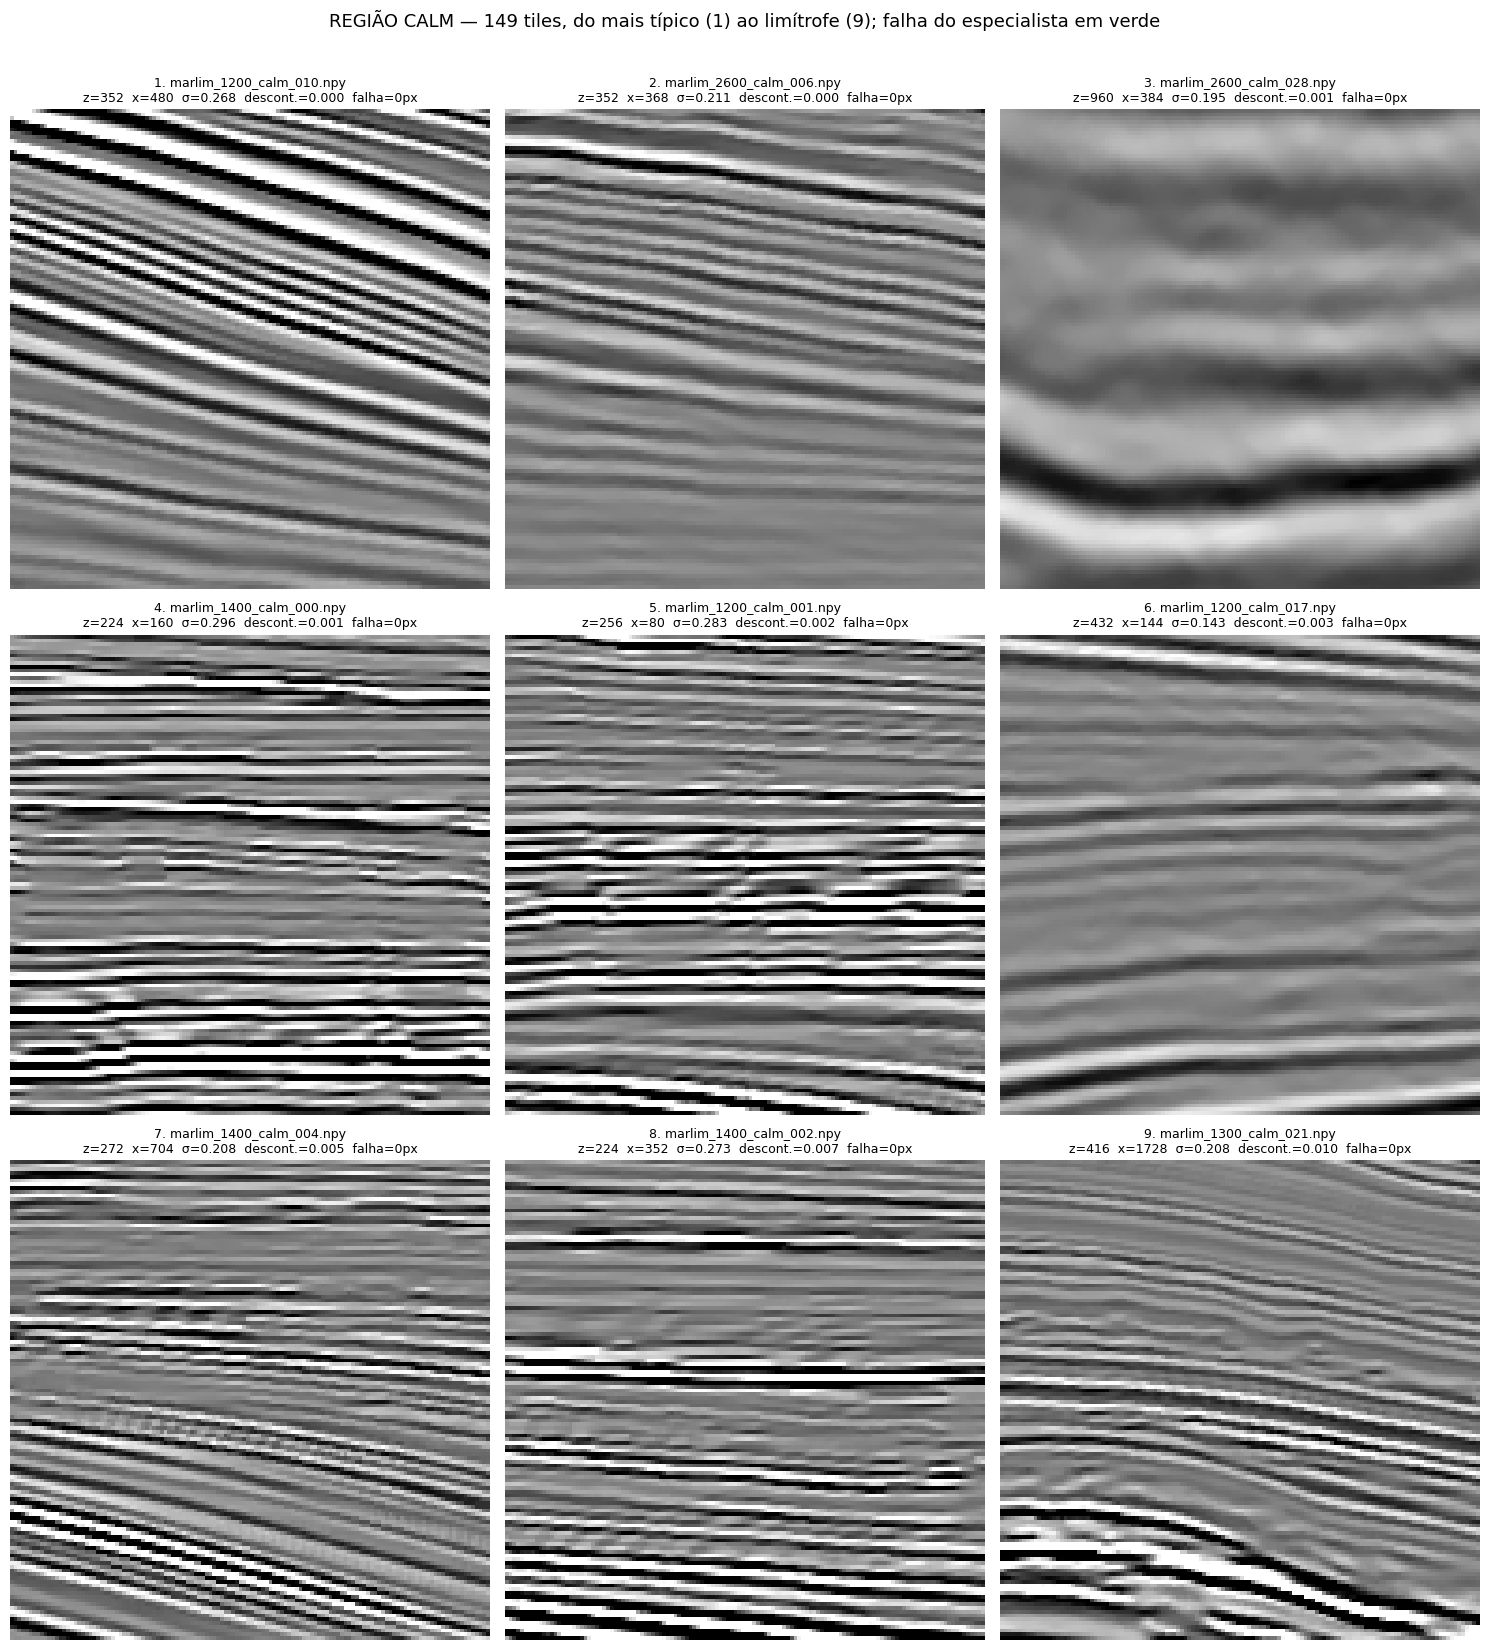

In [8]:
calmRule  = (tiles.reflective == 1) & (tiles.faultNear == 0) & (tiles.discontinuity <= finder.limits['calm'])
calmIndex = finder.export('calm', calmRule, -tiles.discontinuity)

finder.show('calm', calmIndex)

# REGIÃO FAULTED
Tile inteiro no intervalo refletivo e **cruzado por pelo menos `TILE` px de falha anotada** — o
equivalente a uma falha atravessando o tile de cima a baixo. A falha vem do especialista, que é quem
decide o que é falha; a sísmica só garante que o tile não pega água nem a zona morta. Os tiles com
mais falha entram primeiro.

faulted: 4795 candidatos -> 188 tiles {'1200': 44, '1300': 37, '1400': 36, '2600': 71} em files/faulted


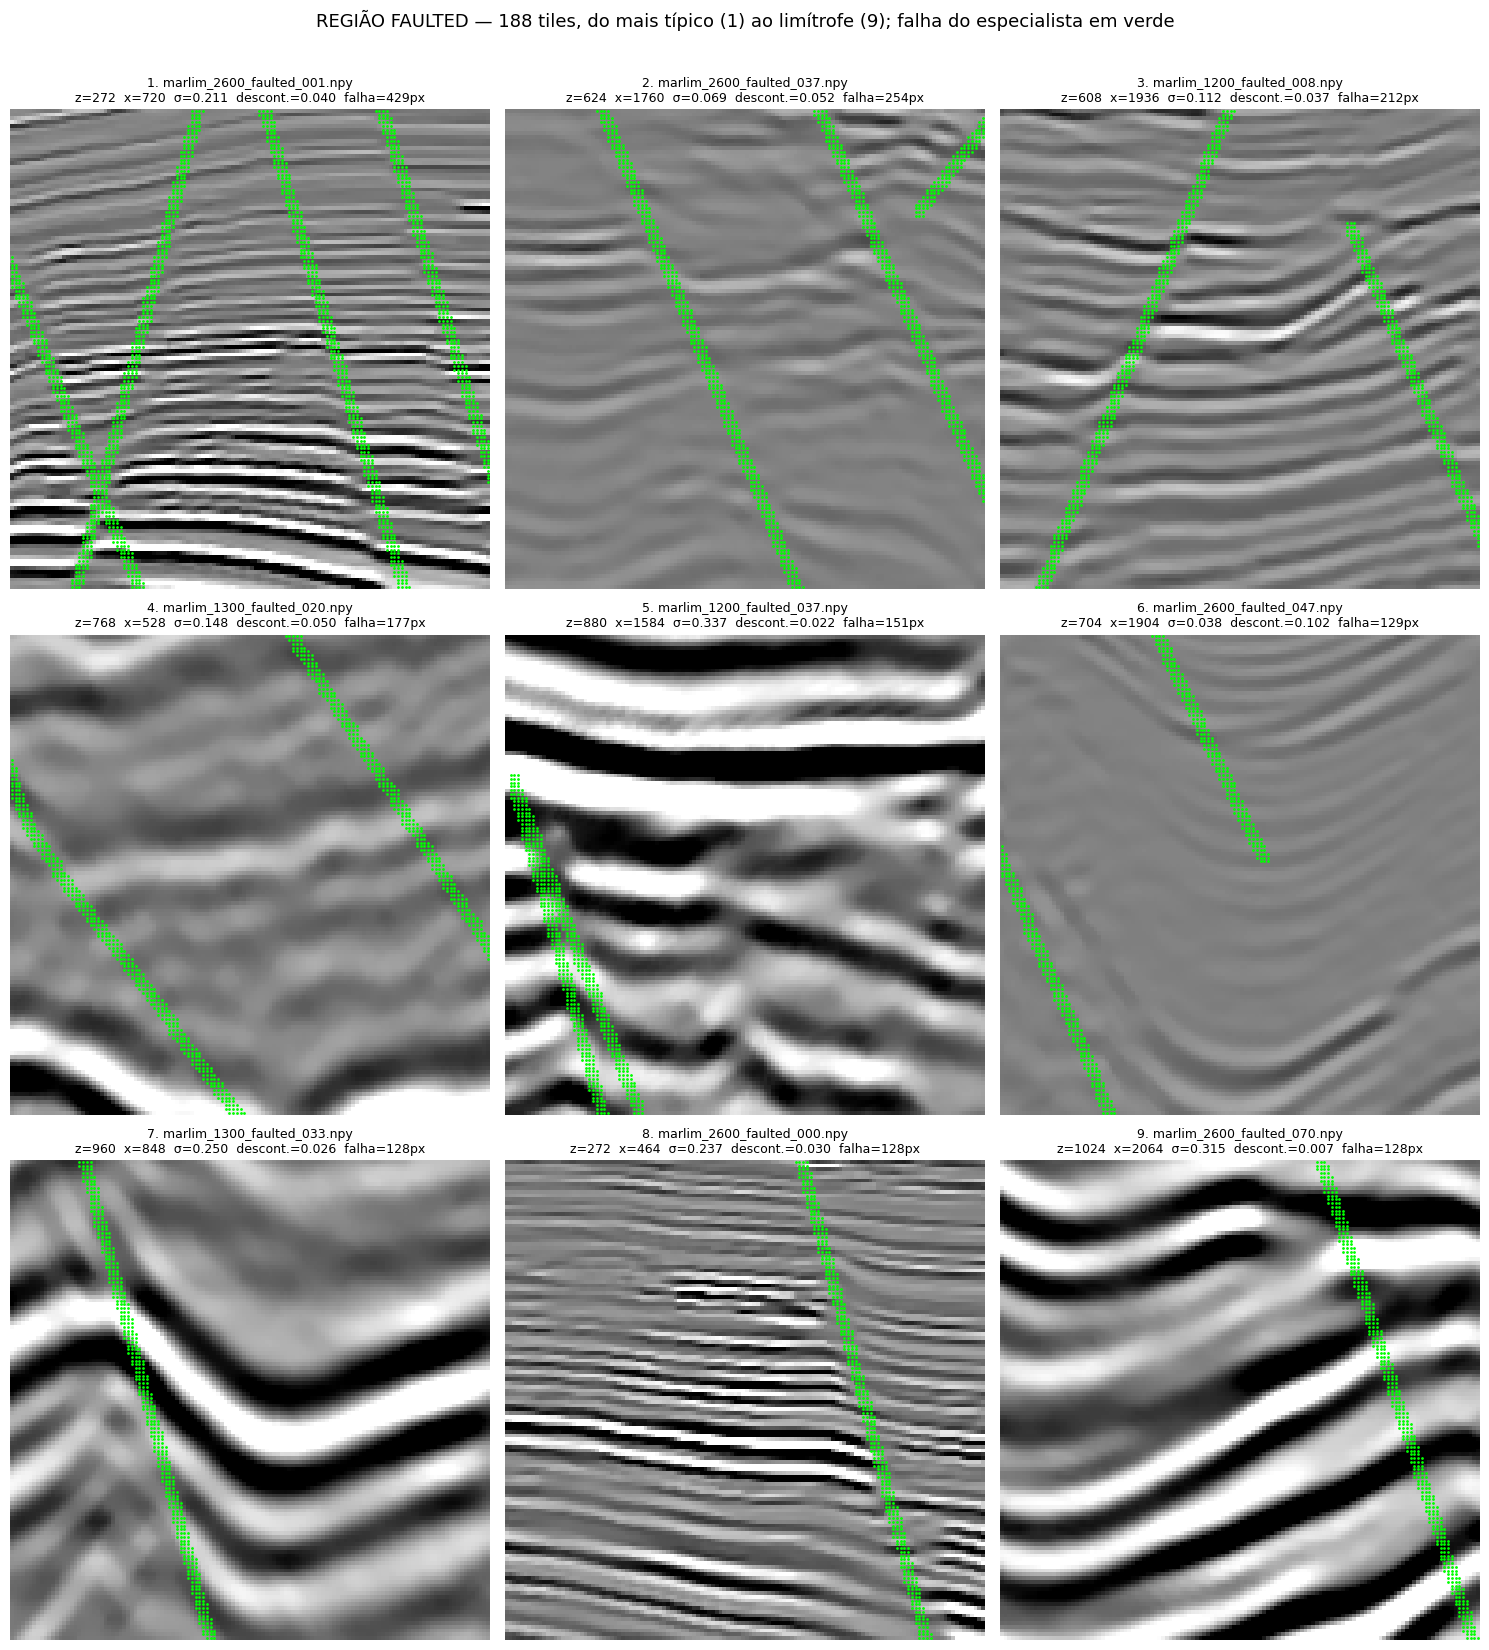

In [9]:
faultedRule  = (tiles.reflective == 1) & (tiles.faultLength >= TILE)
faultedIndex = finder.export('faulted', faultedRule, tiles.faultLength)

finder.show('faulted', faultedIndex)

# REGIÃO DEAD
Tile inteiro abaixo do topo da zona morta, **nenhum voxel com envelope de refletor vivo** e nenhuma
falha anotada a menos de `FAULT_GAP` px — no `2600` o especialista puxa as falhas até z ≈ 1500, e
esses tiles ficam de fora por serem ambíguos. Os de menor energia entram primeiro. A escala é a mesma
[0,1] das outras regiões, então o tile morto aparece quase liso; o σ no título mostra o contraste.

dead: 3150 candidatos -> 123 tiles {'1200': 31, '1300': 41, '1400': 35, '2600': 16} em files/dead


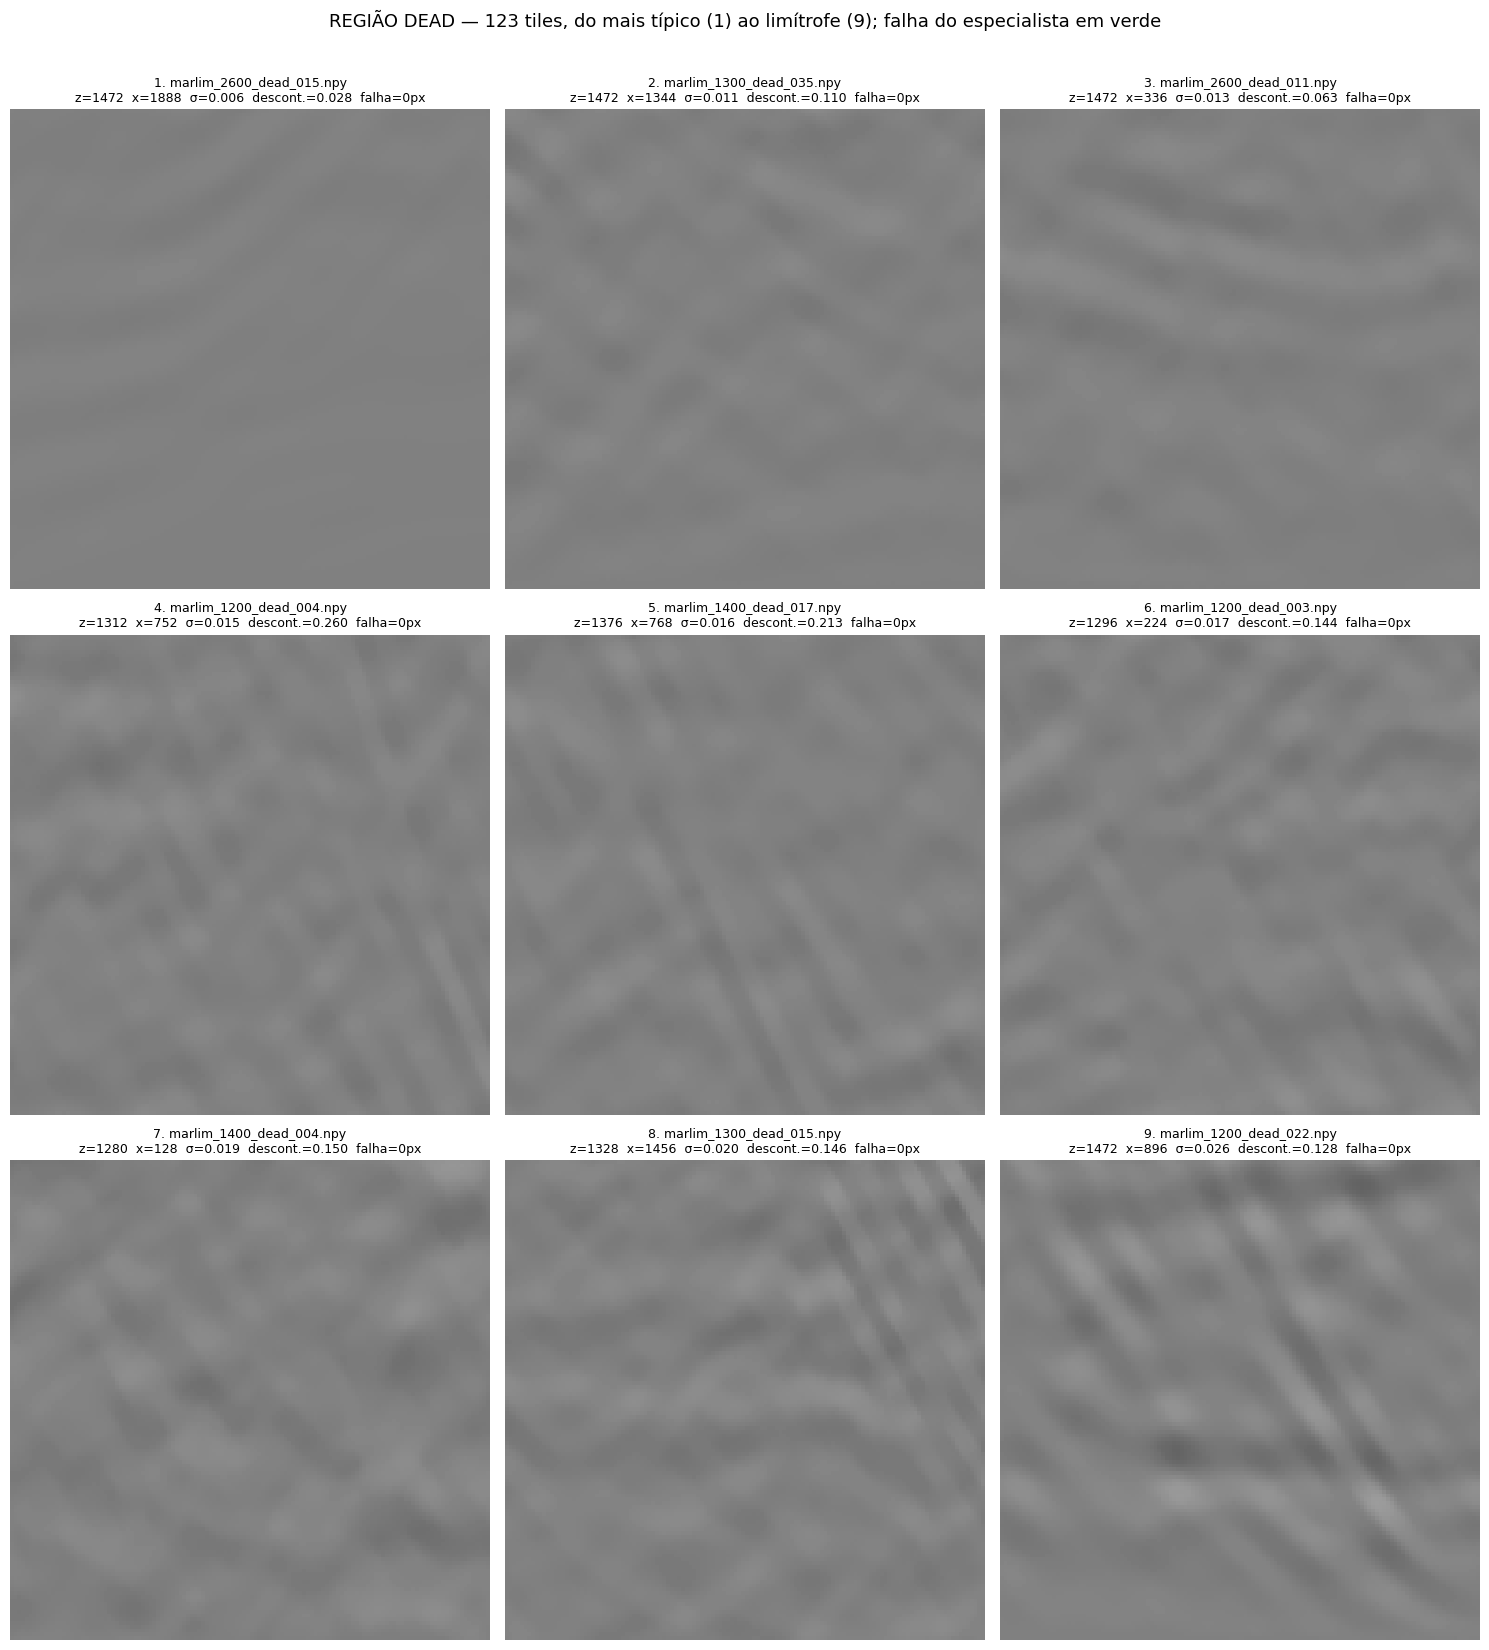

In [10]:
deadRule  = (tiles.deadZone == 1) & (tiles.alive == 0) & (tiles.faultNear == 0)
deadIndex = finder.export('dead', deadRule, -tiles.rms)

finder.show('dead', deadIndex)

# CONFERÊNCIA
Os tiles das três regiões sobre a inline anotada de cada patch, com o fundo do mar em ciano e o topo
da zona morta em laranja. Depois `check` relê cada arquivo — shape, tipo, faixa e conteúdo idêntico
ao do slab —, refaz as medidas de cada tile somando os mapas direto na janela dele, o que pegaria
qualquer deslocamento entre a grade e o tile gravado, e confere a sobreposição e o conteúdo das pastas.

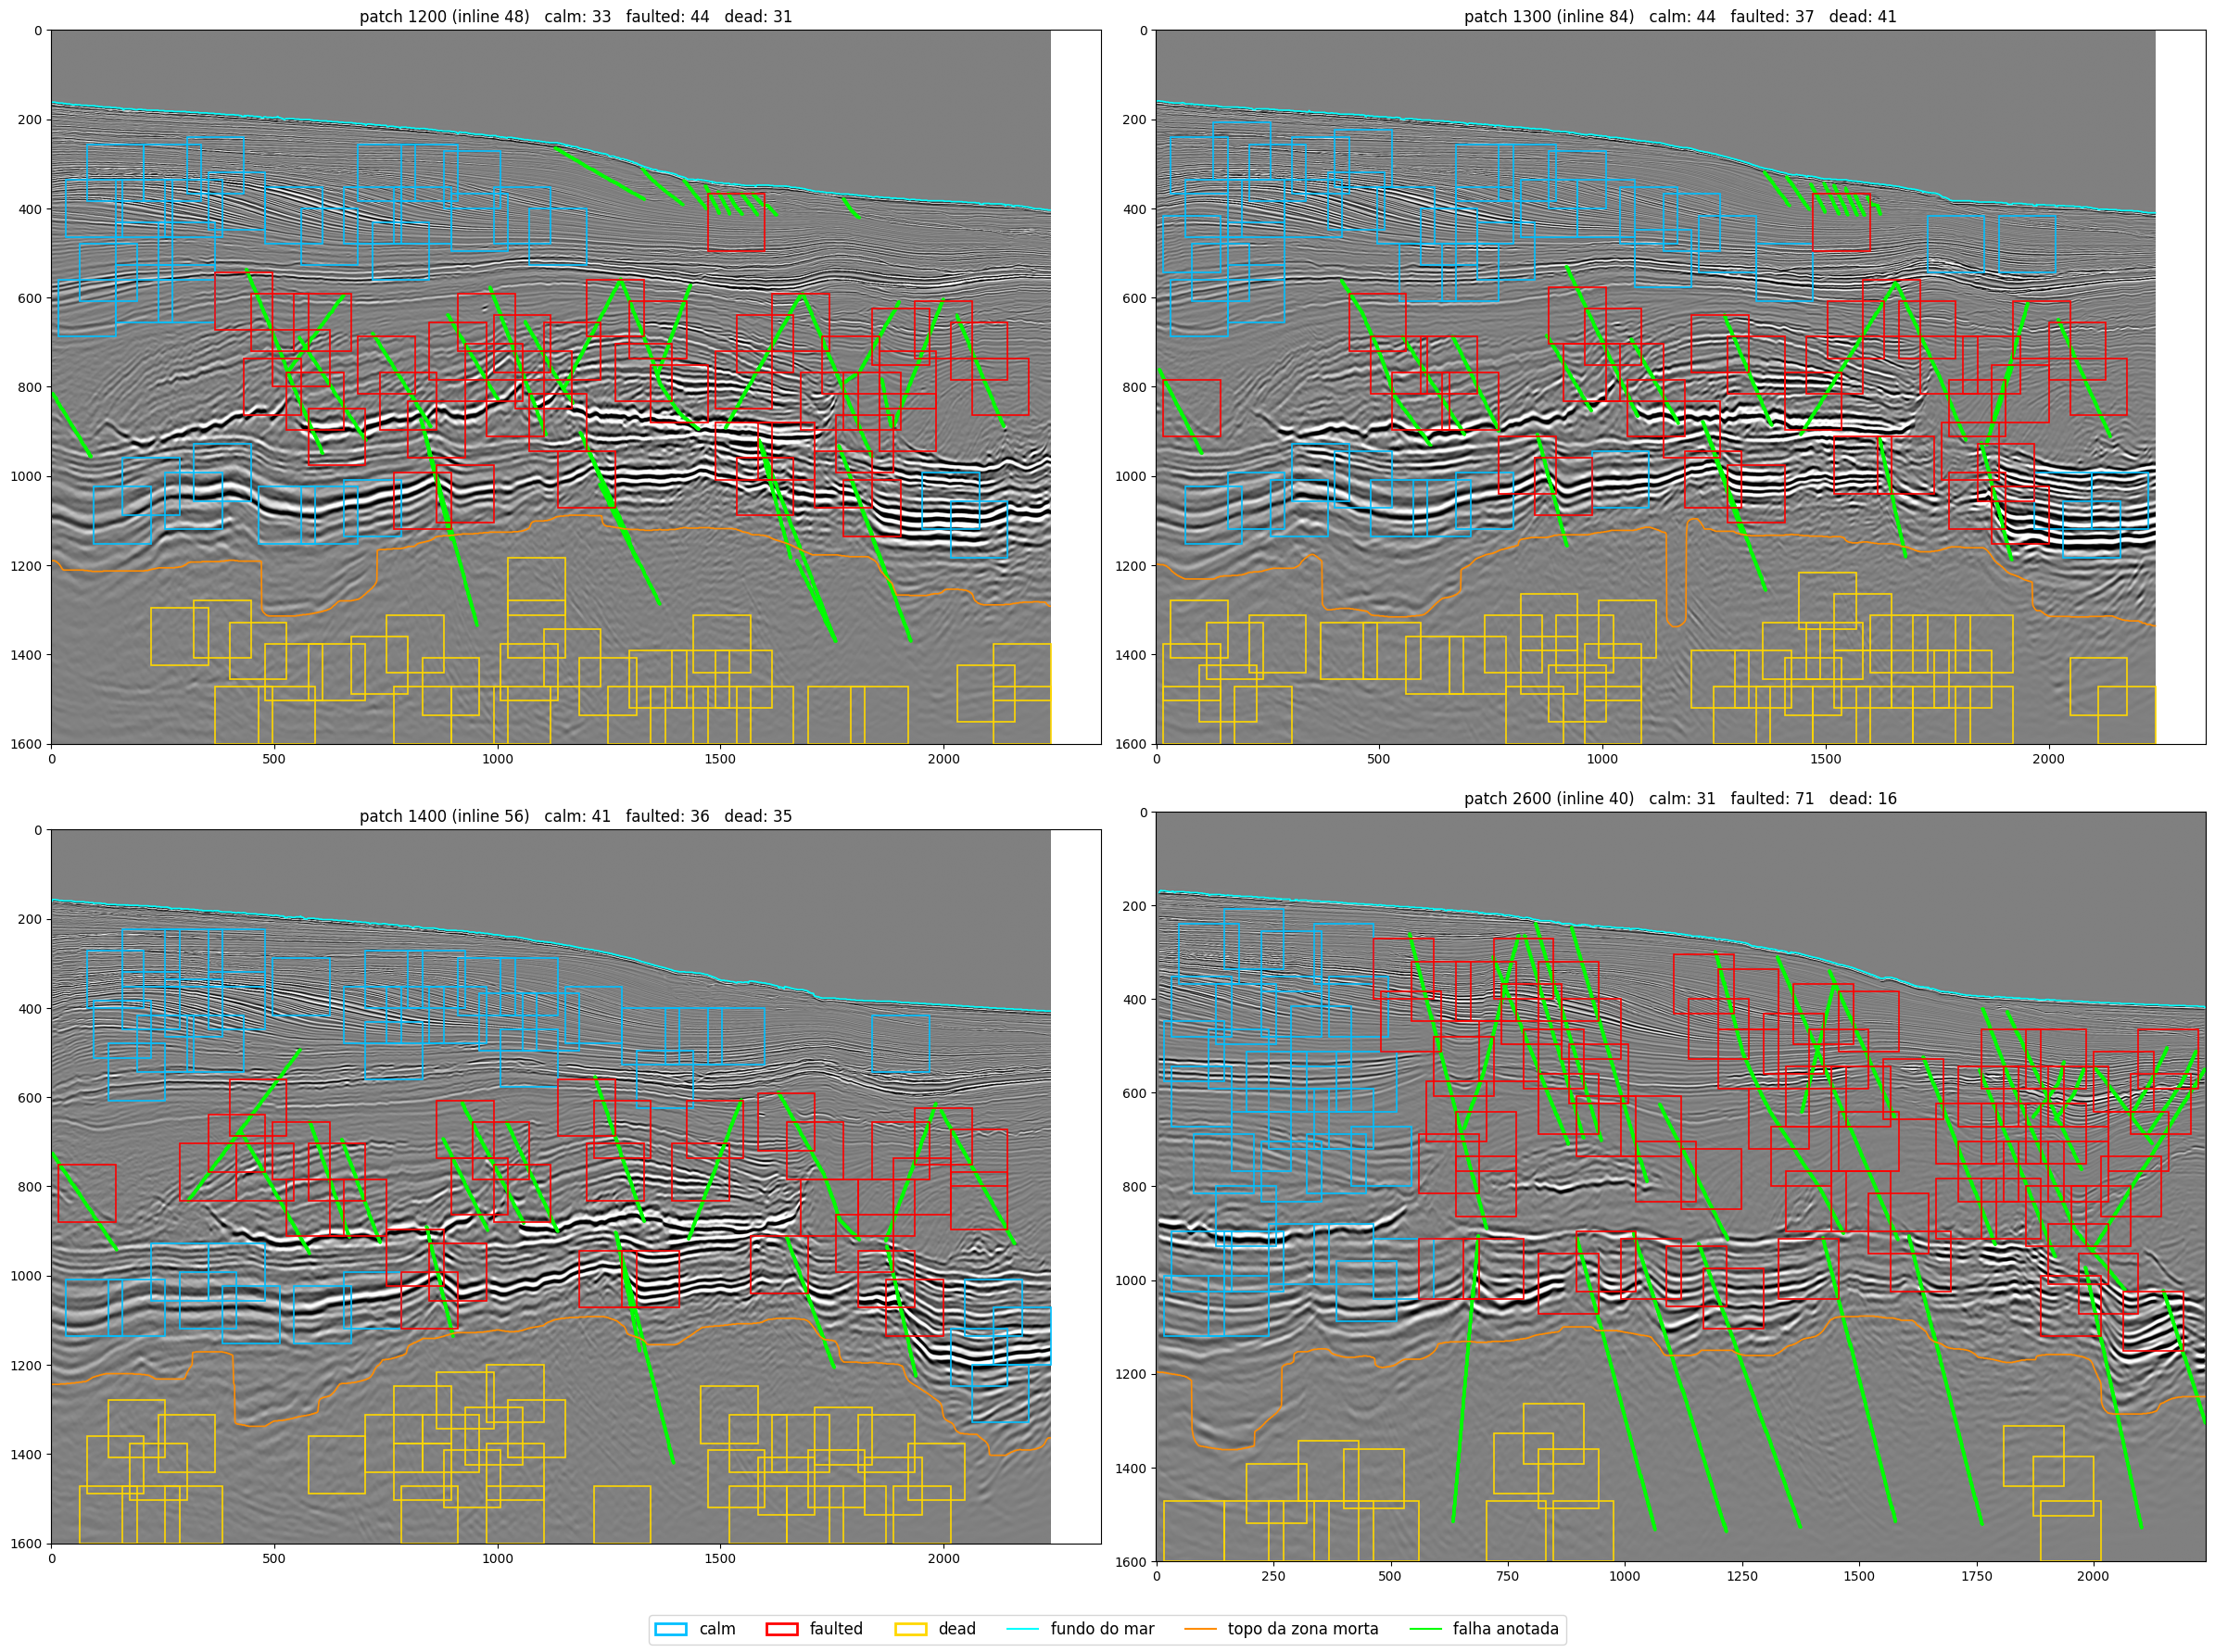

In [11]:
INDEX = pd.concat([calmIndex, faultedIndex, deadIndex], ignore_index=True)
INDEX.to_csv(f'{OUT_DIR}/DataBase.csv', index=False)

finder.plot(INDEX)

In [ ]:
counts  = finder.check(INDEX)
summary = INDEX.groupby('region').agg(
    tiles=('id', 'size'), z_topo=('z0', 'min'),
    z_base=('z0', lambda z: z.max() + TILE), sigma=('img_std', 'median'),
    vivo=('alive', 'median'), descontinuidade=('discontinuity', 'median'),
    falha_px=('faultLength', 'median')).reindex(list(COLORS)
)

pd.concat([counts, summary], axis=1).round(4)

conferindo:   0%|          | 0/460 [00:00<?, ?it/s]

conferindo: 100%|██████████| 460/460 [00:10<00:00, 45.57it/s] 


,1200,1300,1400,2600,tiles,z_topo,z_base,sigma,vivo,descontinuidade,falha_px
region,,,,,,,,,,,
calm,33,44,41,31,149,208,1328,0.1921,1.0000,0.0022,0.0
faulted,44,37,36,71,188,272,1152,0.1457,0.9713,0.0396,151.0
dead,31,41,35,16,123,1184,1600,0.0161,0.0000,0.1277,0.0


: 